0mM TEMPO: B = 0.1107 * I^0.6366  (R^2 = 0.9921)
1mM TEMPO: B = 0.0928 * I^0.6326  (R^2 = 0.9860)
5mM TEMPO: B = 0.0562 * I^0.6990  (R^2 = 0.9857)


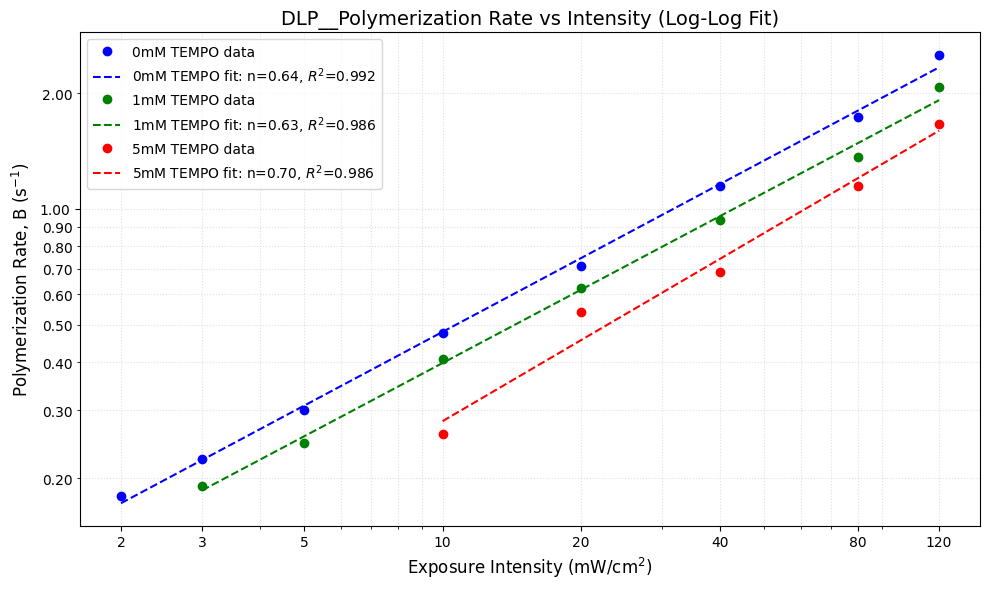

0mM TEMPO: inhibition time C= 8.2971 * I^-0.6044  (R^2 = 0.9559)
1mM TEMPO: inhibition time C= 21.2942 * I^-0.7066  (R^2 = 0.8639)
5mM TEMPO: inhibition time C= 61.4339 * I^-0.8365  (R^2 = 0.9981)


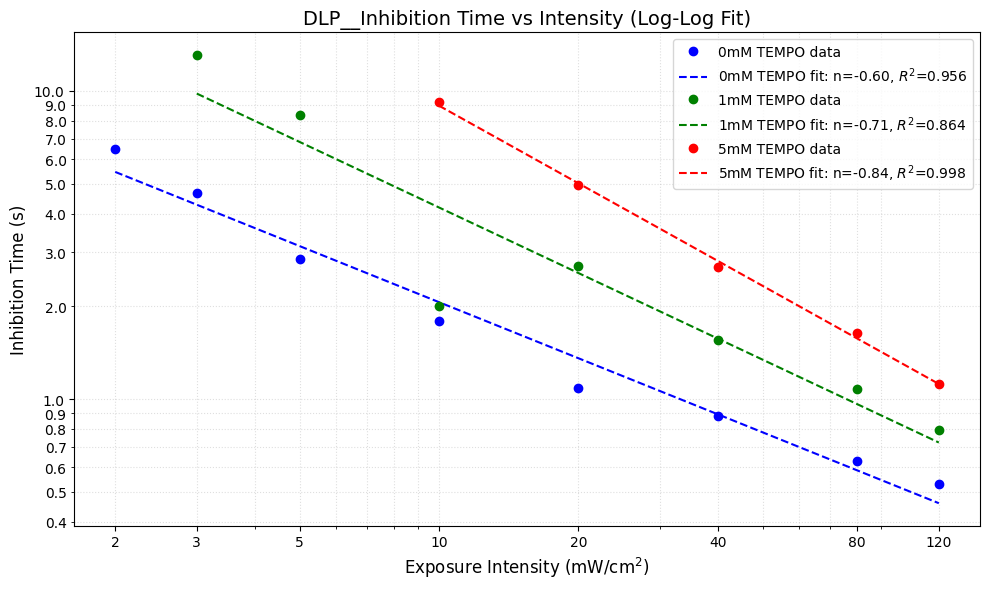

In [ ]:
#Zak asked for New data from Jack 20/09/10  ON DLP SYSTEM
# 0/1/5mMol TEMPO 3,5,10,20,40,80,120mW/cm2
#Log-log (power-law) fit of polymerization rate B (and Inhibition Time)vs excitation intensity, analogous to Figure 2C in
#O'Dea, Scruggs, Page, Adv. Funct. Mater. 2026, 36, e30758 (rp ~ I^n; Type I slope=0.64, Type II slope=0.53)
#https://advanced.onlinelibrary.wiley.com/doi/epdf/10.1002/adfm.202530758 Reference sources
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, ScalarFormatter,FixedLocator, FuncFormatter

#ax = plt.gca()

datasets = {
    '0mM TEMPO': {
        'intensity': np.array([2,3,5,10,20,40,80,120], dtype=float),
        'rate': np.array([0.1802,0.2245,0.2999,0.4763,0.7106,1.149,1.7355,2.5144]),
        'inhibition_time': np.array([6.4901,4.6711,2.8495,1.7922,1.0868,0.8813,0.6279,0.5294]),
        'color': 'blue',
    },
    '1mM TEMPO': {
       'intensity': np.array([3,5,10,20,40,80,120], dtype=float),
       'rate': np.array([0.1910,0.2473,0.4079,0.6215,0.9368,1.3677,2.0772]),
       'inhibition_time': np.array([13.0933,8.3269,2.0029,2.7105,1.5537,1.0743,0.7950]),
       'color': 'green',
    },
    '5mM TEMPO': {
        'intensity': np.array([10,20,40,80,120], dtype=float),
        'rate': np.array([0.2600,0.53875,0.6872,1.1439,1.6582]),
        'inhibition_time': np.array([9.1821,4.9345,2.6776,1.6381,1.1155]),
        'color': 'red',
    },
}

plt.figure(figsize=(10, 6))
ax = plt.gca()
for label, d in datasets.items():
    I, b, color = d['intensity'], d['rate'], d['color']
    log_I, log_b = np.log10(I), np.log10(b)

    n_fit, log_k = np.polyfit(log_I, log_b, 1)
    b_fit = 10**log_k * I**n_fit
    r2 = 1 - np.sum((b - b_fit)**2) / np.sum((b - np.mean(b))**2)

    plt.loglog(I, b, 'o', color=color, label=f'{label} data')
    I_smooth = np.logspace(np.log10(I.min()), np.log10(I.max()), 50)
    
    plt.loglog(I_smooth, 10**log_k * I_smooth**n_fit, '--', color=color,
               label=f'{label} fit: n={n_fit:.2f}, $R^2$={r2:.3f}')

    print(f'{label}: B = {10**log_k:.4f} * I^{n_fit:.4f}  (R^2 = {r2:.4f})')

plt.xlabel('Exposure Intensity (mW/cm$^2$)',fontsize=12)
plt.ylabel('Polymerization Rate, B (s$^{-1}$)',fontsize=12)
plt.title("DLP__Polymerization Rate vs Intensity (Log-Log Fit)",fontsize=14)
# --- finer ticks ---
ax.xaxis.set_minor_locator(LogLocator(subs=np.arange(2, 10) * 0.1))
ax.xaxis.set_major_locator(FixedLocator([2, 3, 5, 10, 20, 40, 80, 120]))
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x:g}'))
ax.yaxis.set_minor_locator(LogLocator(subs=np.arange(2, 10) * 0.1))
ax.yaxis.set_minor_formatter(ScalarFormatter())
ax.yaxis.set_major_formatter(ScalarFormatter())
plt.legend()
plt.grid(True, which='both', ls=':', alpha=0.4)
plt.tight_layout()
plt.show()

# Log-log (power-law) fit of inhibition time vs excitation intensity

plt.figure(figsize=(10, 6))
ax = plt.gca()
for label, d in datasets.items():
    intensity = d['intensity']
    inhibition_time = d['inhibition_time']
    color = d['color']
    log_intensity, log_time = np.log10(intensity), np.log10(inhibition_time)

    slope, log_k = np.polyfit(log_intensity, log_time, 1)
    time_fit = 10**log_k * intensity**slope
    r2 = 1 - np.sum((inhibition_time - time_fit)**2) / np.sum((inhibition_time - np.mean(inhibition_time))**2)

    plt.loglog(intensity, inhibition_time, 'o', color=color, label=f'{label} data')
    intensity_smooth = np.logspace(np.log10(intensity.min()), np.log10(intensity.max()), 50)
    fit_values = 10**log_k * intensity_smooth**slope
    plt.loglog(intensity_smooth, fit_values, '--', color=color,
               label=f'{label} fit: n={slope:.2f}, $R^2$={r2:.3f}')

    # annotation_x = intensity_smooth[int(0.72 * len(intensity_smooth))]
    # annotation_y = 10**log_k * annotation_x**slope
    # ax.annotate(f'slope = {slope:.2f}', (annotation_x, annotation_y),
    #             color=color, fontsize=12, ha='right', va='bottom',
    #             xytext=(-50, -10), textcoords='offset points')

    print(f'{label}: inhibition time C= {10**log_k:.4f} * I^{slope:.4f}  (R^2 = {r2:.4f})')

plt.xlabel('Exposure Intensity (mW/cm$^2$)', fontsize=12)
plt.ylabel('Inhibition Time (s)', fontsize=12)
plt.title('DLP__Inhibition Time vs Intensity (Log-Log Fit)', fontsize=14)
ax.xaxis.set_minor_locator(LogLocator(subs=np.arange(2, 10) * 0.1))
ax.xaxis.set_major_locator(FixedLocator([2, 3, 5, 10, 20, 40, 80, 120]))
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x:g}'))
ax.yaxis.set_minor_locator(LogLocator(subs=np.arange(2, 10) * 0.1))
ax.yaxis.set_minor_formatter(ScalarFormatter())
ax.yaxis.set_major_formatter(ScalarFormatter())
plt.legend()
plt.grid(True, which='both', ls=':', alpha=0.4)
plt.tight_layout()
plt.show()


In [ ]:
#This is for 0mM TEMPO (Jack Shared on 26/09/01)
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

#TEMPO_0mM_a=[0.9730,0.9528,0.9581]
TEMPO_0mM_b=[0.8707,1.0447,1.1906,1.3293,1.5562,1.9823]
TEMPO_0mM_c=[1.0273,0.8405,0.6985,0.6144,0.5320,0.3726]
TMEPO_0mM_intensity=[30,40,50,60,80,120]


slope,inter=np.polyfit(TMEPO_0mM_intensity,TEMPO_0mM_b,1)
print(f"Slope: {slope:.4f}, Intercept: {inter:.4f}")
b_fit = slope*np.array(TMEPO_0mM_intensity) + inter
r2_lin = 1 - np.sum((np.array(TEMPO_0mM_b) - b_fit)**2) / np.sum((np.array(TEMPO_0mM_b) - np.mean(TEMPO_0mM_b))**2)
print(f"Linear fit R^2: {r2_lin:.4f}")
print(f'Fitted inhibition time(s): {np.array(TEMPO_0mM_c)}')
print(f'Fitted inhibition energy(mJ/cm2): {np.array(TEMPO_0mM_c)*np.array(TMEPO_0mM_intensity)}')
print(f'Average Inhibition Energy(mJ/cm2): {np.average(np.array(TEMPO_0mM_c)*np.array(TMEPO_0mM_intensity)):.4f}')

plt.scatter(TMEPO_0mM_intensity,TEMPO_0mM_b, label='Data Points')
plt.plot(TMEPO_0mM_intensity, slope*np.array(TMEPO_0mM_intensity) + inter, 
         linestyle='--', label=f'Linear Fit: y = {slope:.4f}x + {inter:.4}, $R^2$ = {r2_lin:.4f}')
plt.xlabel('Intensity')
plt.ylabel('b')
plt.title('Absorption vs Intensity_0mM TEMPO')
plt.legend()
plt.show()

def fit_func(x,a):
    return a/x
popt, pcov = curve_fit(fit_func, TMEPO_0mM_intensity, TEMPO_0mM_c)
a_err = np.sqrt(np.diag(pcov))[0]
c_fit = fit_func(np.array(TMEPO_0mM_intensity), popt[0])
rmse_curve = np.sqrt(np.mean((np.array(TEMPO_0mM_c) - c_fit)**2))
print(f"Fitted parameter a: {popt[0]:.4f} ± {a_err:.4f}")
print(f"Curve fit RMSE: {rmse_curve:.4f}")

plt.figure()
plt.scatter(TMEPO_0mM_intensity,TEMPO_0mM_c, label='Data Points')
plt.plot(TMEPO_0mM_intensity, fit_func(TMEPO_0mM_intensity, popt[0]), 'r--', label=f'Fit: y = a/x, $a$ = {popt[0]:.3f} ± {a_err:.3f}, RMSE = {rmse_curve:.3f}')
plt.title('Fitted Inhibition Time_0mM TEMPO')
plt.xlabel('Intensity')
plt.ylabel('Inhibition Time')
plt.legend()
plt.show()

In [ ]:
#This is for 5mM TEMPO (Jack Shared on 26/09/01)
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

#TEMPO_0mM_a=[0.9730,0.9528,0.9581]
TEMPO_0mM_b=[0.5625,0.6443,0.7798,0.9445,1.2024,1.3228,1.5049]
TEMPO_0mM_c=[3.8170,2.6200,2.4345,2.0319,1.6434,1.3730,1.0482]
TMEPO_0mM_intensity=[30,40,50,60,80,100,120]


slope,inter=np.polyfit(TMEPO_0mM_intensity,TEMPO_0mM_b,1)
print(f"Slope: {slope:.4f}, Intercept: {inter:.4f}")
b_fit = slope*np.array(TMEPO_0mM_intensity) + inter
r2_lin = 1 - np.sum((np.array(TEMPO_0mM_b) - b_fit)**2) / np.sum((np.array(TEMPO_0mM_b) - np.mean(TEMPO_0mM_b))**2)
print(f"Linear fit R^2: {r2_lin:.4f}")
print(f'Fitted inhibition time(s): {np.array(TEMPO_0mM_c)}')
print(f'Fitted inhibition energy(mJ/cm2): {np.array(TEMPO_0mM_c)*np.array(TMEPO_0mM_intensity)}')
print(f'Average Inhibition Energy(mJ/cm2): {np.average(np.array(TEMPO_0mM_c)*np.array(TMEPO_0mM_intensity)):.4f}')

plt.scatter(TMEPO_0mM_intensity,TEMPO_0mM_b, label='Data Points')
plt.plot(TMEPO_0mM_intensity, slope*np.array(TMEPO_0mM_intensity) + inter, 
         linestyle='--', label=f'Linear Fit: y = {slope:.4f}x + {inter:.4}, $R^2$ = {r2_lin:.4f}')
plt.xlabel('Intensity')
plt.ylabel('b')
plt.title('Absorption vs Intensity_5mM TEMPO')
plt.legend()
plt.show()

def fit_func(x,a):
    return a/x
popt, pcov = curve_fit(fit_func, TMEPO_0mM_intensity, TEMPO_0mM_c)
a_err = np.sqrt(np.diag(pcov))[0]
c_fit = fit_func(np.array(TMEPO_0mM_intensity), popt[0])
rmse_curve = np.sqrt(np.mean((np.array(TEMPO_0mM_c) - c_fit)**2))
print(f"Fitted parameter a: {popt[0]:.4f} ± {a_err:.4f}")
print(f"Curve fit RMSE: {rmse_curve:.4f}")

plt.figure()
plt.scatter(TMEPO_0mM_intensity,TEMPO_0mM_c, label='Data Points')
plt.plot(TMEPO_0mM_intensity, fit_func(TMEPO_0mM_intensity, popt[0]), 'r--', label=f'Fit: y = a/x, $a$ = {popt[0]:.3f} ± {a_err:.3f}, RMSE = {rmse_curve:.3f}')
plt.title('Fitted Inhibition Time_5mM TEMPO')
plt.xlabel('Intensity')
plt.ylabel('Inhibition Time')
plt.legend()
plt.show()